# Feature Selection for Multiclass Problems with ShapRFECV

This tutorial demonstrates how to use `ShapRFECV` for feature selection with multiclass classification problems.
We'll explore the special parameters and aggregation methods available for handling multiple classes.

## Introduction to Multiclass Feature Selection

When dealing with multiclass problems (more than two classes), feature importance becomes more complex.
A feature might be important for distinguishing between certain classes but not others.

The `probatus` library's `ShapRFECV` provides several methods to handle this complexity through
SHAP (SHapley Additive exPlanation) values aggregation.

## Setup and Imports

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
from probatus.features import ShapRFECV

# Set random seed for reproducibility
RANDOM_STATE = 42

## Load and Prepare Multiclass Data

We'll use the Wine dataset, which has 3 classes and 13 features.

In [2]:
# Load the Wine dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target)

# Basic information about the dataset
print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {pd.Series(y).value_counts().to_dict()}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

Dataset shape: (178, 13)
Number of classes: 3
Class distribution: {1: 71, 0: 59, 2: 48}


## Basic ShapRFECV for Multiclass

First, let's perform a basic ShapRFECV without any special multiclass parameters.
By default, for multiclass problems, ShapRFECV uses the SHAP values of the first class.

Feature Elimination:   0%|          | 0/12 [00:00<?, ?it/s]

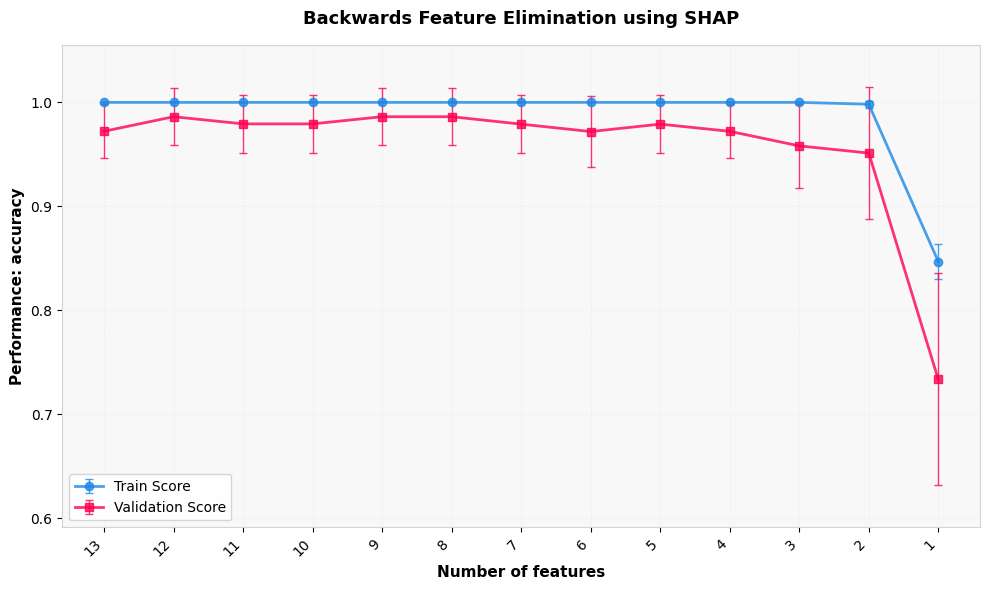

Top 5 features (default aggregation): ['alcohol', 'flavanoids', 'color_intensity', 'hue', 'proline']


In [3]:
# Initialize a model suitable for multiclass classification
model = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

# Basic ShapRFECV
basic_rfe = ShapRFECV(
    model=model,
    step=1,  # Remove one feature at a time
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
)

# Fit the model and get feature importance rankings
basic_report = basic_rfe.fit_compute(X_train, y_train)

# Plot the results
basic_fig = basic_rfe.plot(show=True)

# Get the top 5 features
top_5_features = basic_rfe.get_reduced_features_set(5)
print(f"Top 5 features (default aggregation): {top_5_features}")

## Multiclass Aggregation Methods

Now, let's explore the different multiclass aggregation methods available in ShapRFECV:

1. `max_abs`: Maximum absolute SHAP value across classes for each feature
2. `variance`: Variance of SHAP values across classes
3. `mean_abs`: Mean absolute SHAP value across classes

### Max Absolute SHAP Aggregation

This method selects the maximum absolute SHAP value across all classes for each feature.
It highlights features that are strongly influential for at least one class, regardless of
which class they affect most.

Feature Elimination:   0%|          | 0/12 [00:00<?, ?it/s]

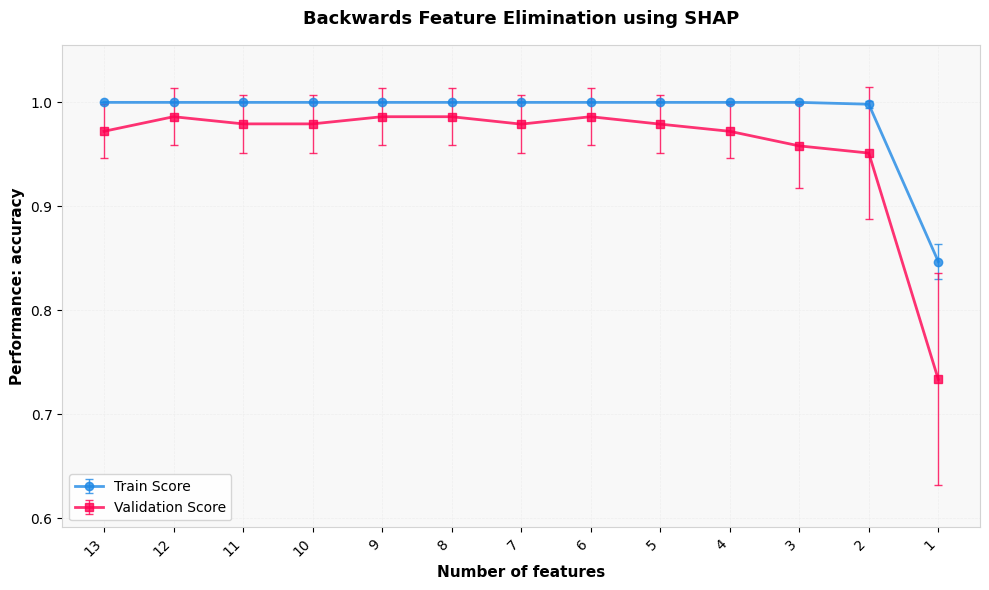

Top 5 features (max_abs): ['alcohol', 'flavanoids', 'color_intensity', 'hue', 'proline']


In [4]:
max_abs_rfe = ShapRFECV(model=model, step=1, cv=5, scoring="accuracy", n_jobs=-1, verbose=1, random_state=RANDOM_STATE)

# Notice we pass the multiclass_aggregation parameter
max_abs_report = max_abs_rfe.fit_compute(X_train, y_train, multiclass_aggregation="max_abs")

max_abs_fig = max_abs_rfe.plot(show=True)

# Get the top 5 features
max_abs_top_5 = max_abs_rfe.get_reduced_features_set(5)
print(f"Top 5 features (max_abs): {max_abs_top_5}")

### Mean Absolute SHAP Aggregation

This method calculates the mean of absolute SHAP values across classes.
It provides the most balanced measure of feature importance by averaging
the absolute contribution across all classes, preventing positive and negative
contributions from canceling each other out.

Feature Elimination:   0%|          | 0/12 [00:00<?, ?it/s]

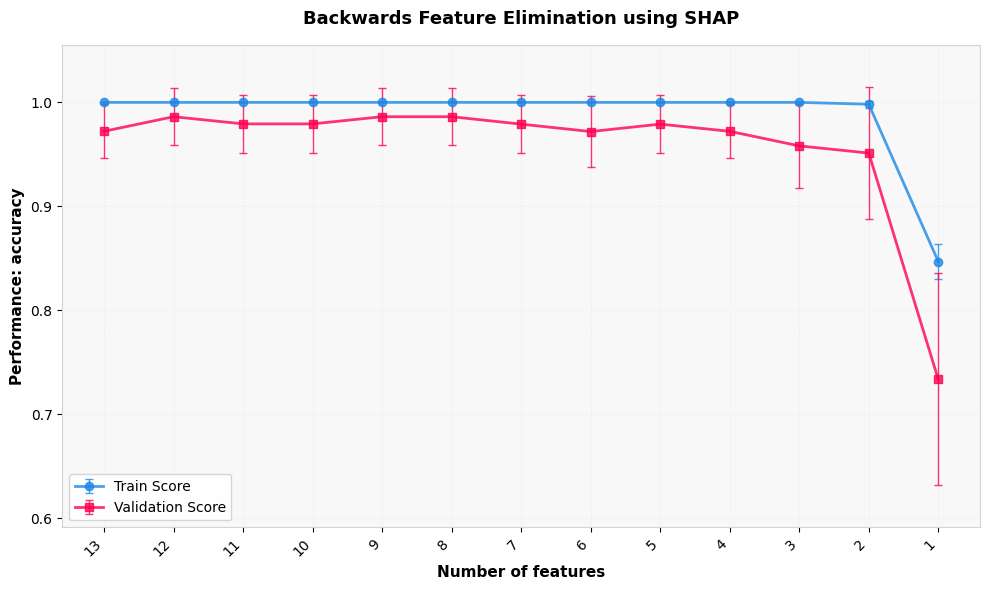

Top 5 features (mean_abs): ['alcohol', 'flavanoids', 'color_intensity', 'hue', 'proline']


In [5]:
mean_abs_rfe = ShapRFECV(model=model, step=1, cv=5, scoring="accuracy", n_jobs=-1, verbose=1, random_state=RANDOM_STATE)

mean_abs_report = mean_abs_rfe.fit_compute(X_train, y_train, multiclass_aggregation="mean_abs")

mean_abs_fig = mean_abs_rfe.plot(show=True)

# Get the top 5 features
mean_abs_top_5 = mean_abs_rfe.get_reduced_features_set(5)
print(f"Top 5 features (mean_abs): {mean_abs_top_5}")

## Selecting a Specific Class

Instead of aggregating, we can focus on a specific class using the `class_selection` parameter.
This is useful when we're particularly interested in features that help identify a specific class.

Feature Elimination:   0%|          | 0/12 [00:00<?, ?it/s]

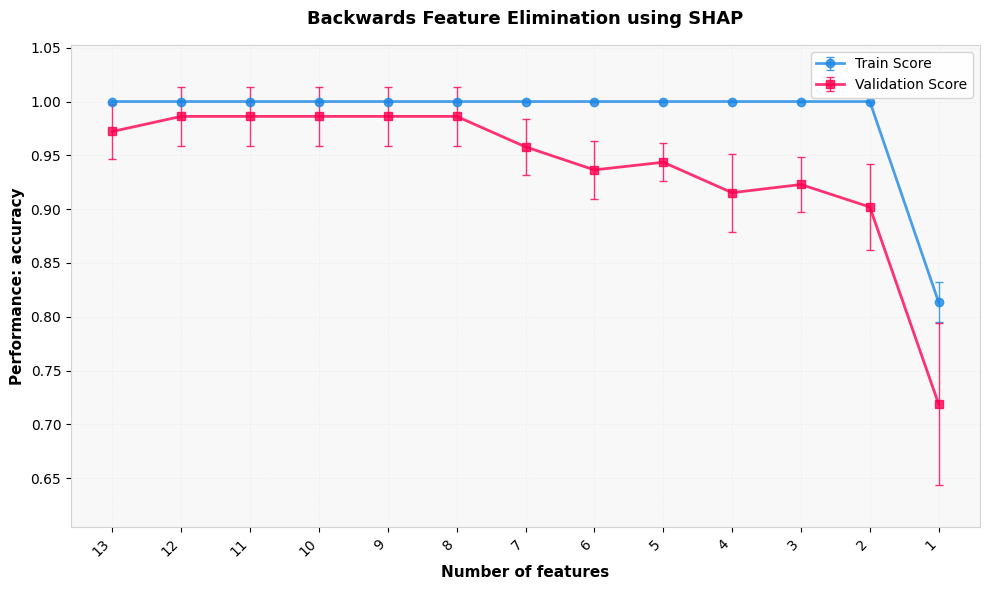

Top 5 features for class 1: ['alcohol', 'malic_acid', 'magnesium', 'color_intensity', 'proline']


In [6]:
# Select features based on their importance for class 1
class_1_rfe = ShapRFECV(model=model, step=1, cv=5, scoring="accuracy", n_jobs=-1, verbose=1, random_state=RANDOM_STATE)

class_1_report = class_1_rfe.fit_compute(X_train, y_train, class_selection=1)  # Select SHAP values for class 1

class_1_fig = class_1_rfe.plot(show=True)

# Get the top 5 features for class 1
class_1_top_5 = class_1_rfe.get_reduced_features_set(5)
print(f"Top 5 features for class 1: {class_1_top_5}")

## Weighting Classes for Imbalanced Problems

For imbalanced multiclass problems, we can use the `weight_type` parameter to weight
SHAP values across classes. Let's create an imbalanced dataset to demonstrate this.

In [7]:
# Create an imbalanced version of the dataset by downsampling some classes
indices_class_0 = np.where(y_train == 0)[0]
indices_class_1 = np.where(y_train == 1)[0]
indices_class_2 = np.where(y_train == 2)[0]

# Keep all class 0, half of class 1, and 20% of class 2
keep_class_1 = np.random.choice(indices_class_1, size=len(indices_class_1) // 2, replace=False)
keep_class_2 = np.random.choice(indices_class_2, size=len(indices_class_2) // 5, replace=False)

imbalanced_indices = np.concatenate([indices_class_0, keep_class_1, keep_class_2])
X_imbalanced = X_train.iloc[imbalanced_indices]
y_imbalanced = y_train.iloc[imbalanced_indices]

print("Original class distribution:", pd.Series(y_train).value_counts().to_dict())
print("Imbalanced class distribution:", pd.Series(y_imbalanced).value_counts().to_dict())

Original class distribution: {1: 57, 0: 47, 2: 38}
Imbalanced class distribution: {0: 47, 1: 28, 2: 7}


### Using Frequency Weighting

This weights each class equally (1/n_classes) regardless of its frequency in the data.

Feature Elimination:   0%|          | 0/12 [00:00<?, ?it/s]

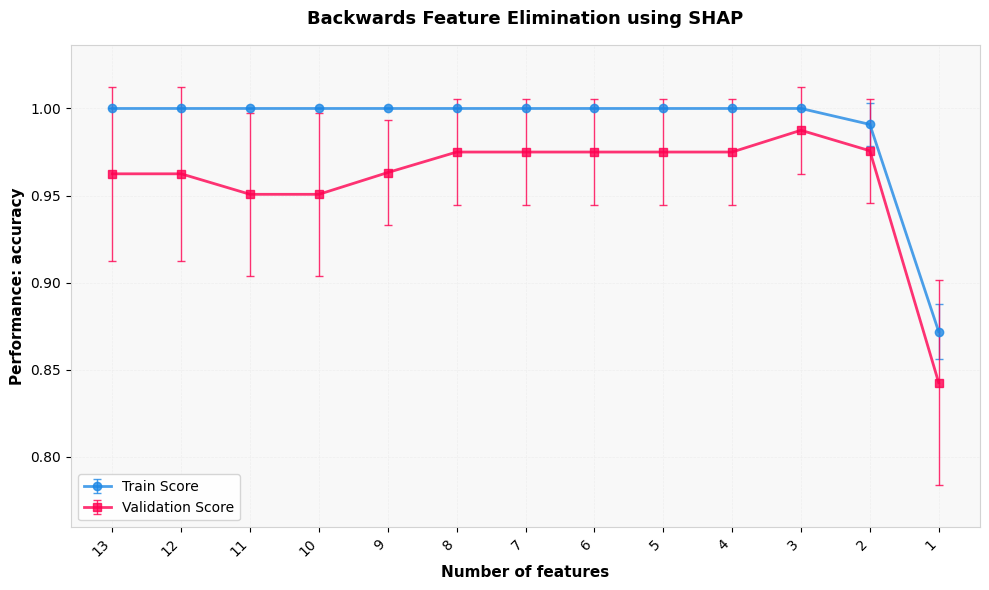

Top 5 features with frequency weighting: ['alcohol', 'total_phenols', 'flavanoids', 'color_intensity', 'proline']


In [8]:
freq_weight_rfe = ShapRFECV(
    model=model, step=1, cv=5, scoring="accuracy", n_jobs=-1, verbose=1, random_state=RANDOM_STATE
)

freq_weight_report = freq_weight_rfe.fit_compute(
    X_imbalanced,
    y_imbalanced,
    multiclass_aggregation="mean_abs",
    weight_type="frequency",  # Equal weights for all classes
)

freq_weight_fig = freq_weight_rfe.plot(show=True)

# Get the top 5 features with frequency weighting
freq_weight_top_5 = freq_weight_rfe.get_reduced_features_set(5)
print(f"Top 5 features with frequency weighting: {freq_weight_top_5}")

### Using Custom Class Weights

We can also provide custom weights for each class. This is useful when we want
to emphasize certain classes over others.

Feature Elimination:   0%|          | 0/12 [00:00<?, ?it/s]

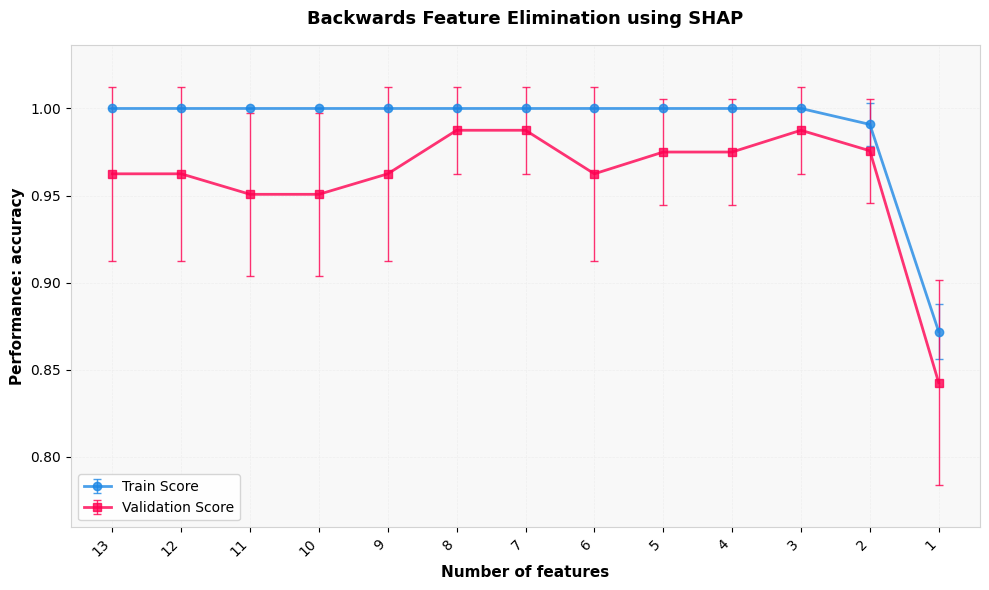

Top 5 features with custom weighting: ['total_phenols', 'flavanoids', 'color_intensity', 'hue', 'proline']


In [9]:
# Define custom weights - give more weight to minority class 2
custom_weights = {0: 0.2, 1: 0.3, 2: 0.5}

custom_weight_rfe = ShapRFECV(
    model=model, step=1, cv=5, scoring="accuracy", n_jobs=-1, verbose=1, random_state=RANDOM_STATE
)

custom_weight_report = custom_weight_rfe.fit_compute(
    X_imbalanced,
    y_imbalanced,
    multiclass_aggregation="mean_abs",
    weight_type=custom_weights,  # Custom weights for each class
)

custom_weight_fig = custom_weight_rfe.plot(show=True)

# Get the top 5 features with custom weighting
custom_weight_top_5 = custom_weight_rfe.get_reduced_features_set(5)
print(f"Top 5 features with custom weighting: {custom_weight_top_5}")

## Comparing Feature Rankings from Different Methods

Let's compare the top features selected by different aggregation methods.

In [10]:
# Function to compare top features from different methods
def compare_top_features(n_features=5):
    methods = {
        "Default": basic_rfe,
        "Max Abs": max_abs_rfe,
        "Mean Abs": mean_abs_rfe,
        "Class 1 Focus": class_1_rfe,
        "Frequency Weighting": freq_weight_rfe,
        "Custom Weighting": custom_weight_rfe,
    }

    results = {}
    for name, rfe in methods.items():
        results[name] = rfe.get_reduced_features_set(n_features)

    return pd.DataFrame({k: pd.Series(v) for k, v in results.items()})


# Compare top 5 features
top_features_comparison = compare_top_features(5)
print("\nComparison of top 5 features from different methods:")
print(top_features_comparison)


Comparison of top 5 features from different methods:
           Default          Max Abs         Mean Abs    Class 1 Focus  \
0          alcohol          alcohol          alcohol          alcohol   
1       flavanoids       flavanoids       flavanoids       malic_acid   
2  color_intensity  color_intensity  color_intensity        magnesium   
3              hue              hue              hue  color_intensity   
4          proline          proline          proline          proline   

  Frequency Weighting Custom Weighting  
0             alcohol    total_phenols  
1       total_phenols       flavanoids  
2          flavanoids  color_intensity  
3     color_intensity              hue  
4             proline          proline  


## Evaluating Feature Sets

Now, let's evaluate how well models perform using the selected feature sets.

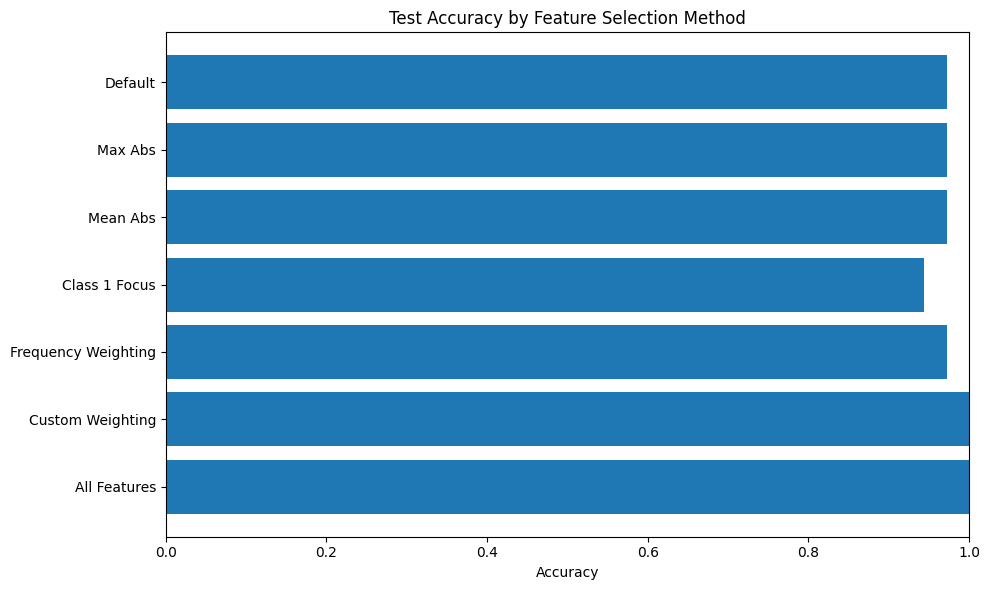

In [11]:
def evaluate_feature_set(features, X_train, y_train, X_test, y_test):
    # Train a model using only the selected features
    model = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
    model.fit(X_train[features], y_train)

    # Evaluate on test set
    y_pred = model.predict(X_test[features])
    return accuracy_score(y_test, y_pred)


# Get top 5 features from each method
feature_sets = {
    "Default": top_5_features,
    "Max Abs": max_abs_top_5,
    "Mean Abs": mean_abs_top_5,
    "Class 1 Focus": class_1_top_5,
    "Frequency Weighting": freq_weight_top_5,
    "Custom Weighting": custom_weight_top_5,
    "All Features": X.columns.tolist(),
}

# Evaluate each feature set
results = {}
for name, features in feature_sets.items():
    accuracy = evaluate_feature_set(features, X_train, y_train, X_test, y_test)
    results[name] = accuracy

# Plot the results
plt.figure(figsize=(10, 6))
methods = list(results.keys())
accuracies = list(results.values())
plt.barh(methods, accuracies)
plt.xlabel("Accuracy")
plt.title("Test Accuracy by Feature Selection Method")
plt.xlim(0, 1)
plt.gca().invert_yaxis()  # Reverse y-axis to have the highest accuracy at the top
plt.tight_layout()
plt.show()

## Conclusion

In this tutorial, we've explored how to use `ShapRFECV` for feature selection in multiclass problems.
We've seen:

1. Different aggregation methods for multiclass SHAP values:
   - `max_abs`: Highlights features influential for at least one class
   - `variance`: Identifies features with varying impact across classes
   - `mean_abs`: Provides balanced importance averaging across classes

2. How to focus on a specific class using `class_selection`

3. How to handle imbalanced multiclass problems using:
   - `weight_type="frequency"`: Equal weights for all classes
   - Custom weight dictionaries: Tailored weights for different classes

The choice of method depends on your specific use case:

- If you want to identify features important for any class, use `max_abs`
- If you're interested in features that discriminate differently between classes, use `variance`
- For a balanced average importance, use `mean_abs`
- If your dataset is imbalanced, consider using appropriate weighting

By leveraging these options, you can perform more nuanced feature selection for multiclass problems,
potentially improving model performance and interpretability.